# IPCC — Análisis de Sensibilidad Comparado
## 5 países · Chile · EE.UU. · Alemania · España · Francia
### Nivel 1: Exclusión de indicadores equivalentes a CASEN
### Nivel 2: Variaciones de pesos dimensionales en M3

**Autor:** Diego Carmine Ortiz | Universidad de Concepción — Ingeniería Industrial  
**Profesor Guía:** Carlos Navarrete | **Co-Guía:** José Oliveros

---

| Dimensión | Peso M3 | Indicadores |
|-----------|---------|-------------|
| Business | 15% | PIB pc · TCAC PIB pc · Densidad empresas |
| Employment | 20% | Tasa ocupación · Tasa desempleo · % Formal · % Calificado |
| Potential | 40% | Brecha ingreso · Cap. subutilizado · Clase media |
| Entrepreneurial | 25% | Educ. terciaria · Escolaridad promedio |

**Nota:** España y Francia tienen arquitecturas reducidas en Potential y Entrepreneurial  
(2 y 1 indicadores respectivamente). Solo los indicadores presentes se excluyen en el Nivel 1.

In [2]:
# ══════════════════════════════════════════════════════════════════════════
# CELDA 1 — CONFIGURACIÓN GENERAL Y CARGA DE DATOS
# ══════════════════════════════════════════════════════════════════════════

import warnings, os, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
warnings.filterwarnings('ignore')

FIGDIR = '/Users/diego/Desktop/MT/graficos/importantes'
os.makedirs(FIGDIR, exist_ok=True)

COLOR_TIER  = {1: '#8B1A1A', 2: '#E07B39', 3: '#A9A9A9'}
MARKER_TIER = {1: '*', 2: 'D', 3: 'o'}
SIZE_TIER   = {1: 280,  2: 160,  3: 90}

plt.rcParams.update({
    'font.family': 'DejaVu Serif',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E8E0D8', 'grid.linewidth': 0.5,
})

# ── Carga de CSVs ────────────────────────────────────────────────────────────
PATH_BASE = '/Users/diego/Desktop/MT/prototipo_ccpi/data'
PATH_CODE = '/Users/diego/Desktop/MT/code/data'

df_chile    = pd.read_csv(f'{PATH_BASE}/ccpi_chile_m3_2024.csv')
df_eeuu     = pd.read_csv(f'{PATH_CODE}/ccpi_eeuu_3metodos.csv')
df_alemania = pd.read_csv(f'{PATH_CODE}/ccpi_alemania_3metodos.csv')
df_espana   = pd.read_csv(f'{PATH_BASE}/ccpi_espana_m3.csv')
df_francia  = pd.read_csv(f'{PATH_BASE}/ccpi_francia_m3.csv')

# España/Francia: medianas del pool combinado (igual que en IPCC_ESPANA_FRANCIA_M3)
df_esfr = pd.concat([df_espana, df_francia], ignore_index=True)
MED_ESFR_CCPI = df_esfr['CCPI_M3'].median()
MED_ESFR_CONV = df_esfr['conv_pc'].median()


def clasificar_cuadrante(ccpi, y_val, med_ccpi, med_y):
    hi_c = ccpi >= med_ccpi
    hi_y = y_val >= med_y
    if     hi_c and     hi_y: return 'Motor consolidado'
    if not hi_c and     hi_y: return 'Contrapeso emergente'
    if     hi_c and not hi_y: return 'Capital estancada'
    return 'Rezagada'


# ── Configuración por país ───────────────────────────────────────────────────
PAISES_CFG = {
    'Chile': {
        'df': df_chile, 'n_label': 'region', 'cuad_col': 'cuad_M3',
        'y_col': 'tcac_pc',
        'med_ccpi': df_chile['CCPI_M3'].median(),
        'med_y':    df_chile['tcac_pc'].median(),
        'dim_B': ['s_b_pib', 's_b_tcac', 's_b_den'],
        'dim_E': ['s_e_ocu', 's_e_des', 's_e_for', 's_e_cal'],
        'dim_P': ['s_p_bre', 's_p_sub', 's_p_cla'],
        'dim_N': ['s_n_ter', 's_n_esc'],
        'casen': {
            'sin_brecha':      ('P', 's_p_bre'),
            'sin_cap_sub':     ('P', 's_p_sub'),
            'sin_clase_media': ('P', 's_p_cla'),
            'sin_educ_terc':   ('N', 's_n_ter'),
            'sin_escolaridad': ('N', 's_n_esc'),
        },
    },
    'EE.UU.': {
        'df': df_eeuu, 'n_label': 'nombre', 'cuad_col': 'cuadrante',
        'y_col': 'tcac_pc',
        'med_ccpi': df_eeuu['CCPI_M3'].median(),
        'med_y':    df_eeuu['tcac_pc'].median(),
        'dim_B': ['s_gdp', 's_tcac', 's_den'],
        'dim_E': ['s_ocu', 's_des', 's_for', 's_cal'],
        'dim_P': ['s_bre', 's_sub', 's_cls'],
        'dim_N': ['s_ter', 's_esc'],
        'casen': {
            'sin_brecha':      ('P', 's_bre'),
            'sin_cap_sub':     ('P', 's_sub'),
            'sin_clase_media': ('P', 's_cls'),
            'sin_educ_terc':   ('N', 's_ter'),
            'sin_escolaridad': ('N', 's_esc'),
        },
    },
    'Alemania': {
        'df': df_alemania, 'n_label': 'nombre', 'cuad_col': 'cuadrante',
        'y_col': 'tcac_pc',
        'med_ccpi': df_alemania['CCPI_M3'].median(),
        'med_y':    df_alemania['tcac_pc'].median(),
        'dim_B': ['s_gdp', 's_tcac', 's_den'],
        'dim_E': ['s_ocu', 's_des', 's_for', 's_cal'],
        'dim_P': ['s_bre', 's_sub', 's_cls'],
        'dim_N': ['s_ter', 's_esc'],
        'casen': {
            'sin_brecha':      ('P', 's_bre'),
            'sin_cap_sub':     ('P', 's_sub'),
            'sin_clase_media': ('P', 's_cls'),
            'sin_educ_terc':   ('N', 's_ter'),
            'sin_escolaridad': ('N', 's_esc'),
        },
    },
    'España': {
        'df': df_espana, 'n_label': 'region', 'cuad_col': 'cuad_M3',
        'y_col': 'conv_pc',
        'med_ccpi': MED_ESFR_CCPI, 'med_y': MED_ESFR_CONV,
        'dim_B': ['s_b_gdp', 's_b_tcac'],
        'dim_E': ['s_e_emp', 's_e_des', 's_e_for', 's_e_cal'],
        'dim_P': ['s_p_bre', 's_p_cnv'],
        'dim_N': ['s_n_ter'],
        'casen': {
            'sin_brecha':    ('P', 's_p_bre'),
            'sin_educ_terc': ('N', 's_n_ter'),
        },
    },
    'Francia': {
        'df': df_francia, 'n_label': 'region', 'cuad_col': 'cuad_M3',
        'y_col': 'conv_pc',
        'med_ccpi': MED_ESFR_CCPI, 'med_y': MED_ESFR_CONV,
        'dim_B': ['s_b_gdp', 's_b_tcac'],
        'dim_E': ['s_e_emp', 's_e_des', 's_e_for', 's_e_cal'],
        'dim_P': ['s_p_bre', 's_p_cnv'],
        'dim_N': ['s_n_ter'],
        'casen': {
            'sin_brecha':    ('P', 's_p_bre'),
            'sin_educ_terc': ('N', 's_n_ter'),
        },
    },
}

DIM_WEIGHTS = {'B': 0.15, 'E': 0.20, 'P': 0.40, 'N': 0.25}


def recalc_ccpi(df, cfg, excl_por_dim=None):
    """Recalcular CCPI_M3 excluyendo indicadores por dimensión.

    excl_por_dim = {'P': ['s_p_bre'], 'N': ['s_n_ter']} o None
    """
    excl = excl_por_dim or {}
    results = []
    for _, r in df.iterrows():
        scores = {}
        for dk in ['B', 'E', 'P', 'N']:
            cols = [c for c in cfg[f'dim_{dk}']
                    if c not in excl.get(dk, []) and c in r.index]
            scores[dk] = float(np.mean([r[c] for c in cols])) if cols else 0.0
        results.append(
            DIM_WEIGHTS['B'] * scores['B'] + DIM_WEIGHTS['E'] * scores['E']
            + DIM_WEIGHTS['P'] * scores['P'] + DIM_WEIGHTS['N'] * scores['N']
        )
    return np.array(results)


print('✓ Configuración cargada')
for p, cfg in PAISES_CFG.items():
    df = cfg['df']
    nl = cfg['n_label']
    print(f"  {p:10s}: {len(df):>2d} unidades | "
          f"CCPI_M3 [{df['CCPI_M3'].min():.3f}–{df['CCPI_M3'].max():.3f}] | "
          f"equiv.CASEN: {list(cfg['casen'].keys())}")

✓ Configuración cargada
  Chile     : 16 unidades | CCPI_M3 [0.412–0.551] | equiv.CASEN: ['sin_brecha', 'sin_cap_sub', 'sin_clase_media', 'sin_educ_terc', 'sin_escolaridad']
  EE.UU.    : 13 unidades | CCPI_M3 [0.344–0.548] | equiv.CASEN: ['sin_brecha', 'sin_cap_sub', 'sin_clase_media', 'sin_educ_terc', 'sin_escolaridad']
  Alemania  : 13 unidades | CCPI_M3 [0.500–0.787] | equiv.CASEN: ['sin_brecha', 'sin_cap_sub', 'sin_clase_media', 'sin_educ_terc', 'sin_escolaridad']
  España    : 13 unidades | CCPI_M3 [0.452–0.578] | equiv.CASEN: ['sin_brecha', 'sin_educ_terc']
  Francia   : 13 unidades | CCPI_M3 [0.390–0.581] | equiv.CASEN: ['sin_brecha', 'sin_educ_terc']


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 2 — NIVEL 1: CÁLCULO DE SENSIBILIDAD A EXCLUSIÓN DE INDICADORES
# ══════════════════════════════════════════════════════════════════════════════
nivel1 = {}

for pais, cfg in PAISES_CFG.items():
    df         = cfg['df']
    base_ranks = pd.Series(df['CCPI_M3'].values).rank(ascending=False).values
    resultados = {'base': {'rank': base_ranks, 'rho': 1.0, 'delta': np.zeros(len(df))}}

    # Escenario individual por indicador CASEN-equivalente
    for escenario, (dim_key, col) in cfg['casen'].items():
        new_s  = recalc_ccpi(df, cfg, excl_por_dim={dim_key: [col]})
        new_r  = pd.Series(new_s).rank(ascending=False).values
        rho, _ = spearmanr(base_ranks, new_r)
        resultados[escenario] = {
            'rank': new_r, 'rho': round(float(rho), 4),
            'delta': base_ranks - new_r
        }

    # Escenario sin_CASEN_total: excluir todos simultáneamente
    excl_total = {}
    for _, (dk, c) in cfg['casen'].items():
        excl_total.setdefault(dk, []).append(c)
    new_s_all  = recalc_ccpi(df, cfg, excl_por_dim=excl_total)
    new_r_all  = pd.Series(new_s_all).rank(ascending=False).values
    rho_all, _ = spearmanr(base_ranks, new_r_all)
    resultados['sin_CASEN_total'] = {
        'rank': new_r_all, 'rho': round(float(rho_all), 4),
        'delta': base_ranks - new_r_all
    }

    nivel1[pais] = {
        'base_ranks': base_ranks,
        'resultados': resultados,
        'escenarios': list(cfg['casen'].keys()) + ['sin_CASEN_total'],
    }

    print(f'\n{pais}:')
    for esc, res in resultados.items():
        if esc == 'base': continue
        d = res.get('delta', np.array([0]))
        print(f"  {esc:<22}  ρ={res['rho']:.4f}   max|ΔRank|={int(abs(d).max())}")

print('\n✓ Nivel 1 calculado para los 5 países')



Chile:
  sin_brecha              ρ=0.6882   max|ΔRank|=8
  sin_cap_sub             ρ=0.9147   max|ΔRank|=5
  sin_clase_media         ρ=0.9294   max|ΔRank|=4
  sin_educ_terc           ρ=1.0000   max|ΔRank|=0
  sin_escolaridad         ρ=0.9882   max|ΔRank|=2
  sin_CASEN_total         ρ=0.3941   max|ΔRank|=9

EE.UU.:
  sin_brecha              ρ=0.9176   max|ΔRank|=3
  sin_cap_sub             ρ=0.9835   max|ΔRank|=2
  sin_clase_media         ρ=0.9780   max|ΔRank|=2
  sin_educ_terc           ρ=0.9945   max|ΔRank|=1
  sin_escolaridad         ρ=0.9945   max|ΔRank|=1
  sin_CASEN_total         ρ=0.8791   max|ΔRank|=4

Alemania:
  sin_brecha              ρ=0.9121   max|ΔRank|=4
  sin_cap_sub             ρ=0.9945   max|ΔRank|=1
  sin_clase_media         ρ=0.9890   max|ΔRank|=1
  sin_educ_terc           ρ=0.9945   max|ΔRank|=1
  sin_escolaridad         ρ=0.9945   max|ΔRank|=1
  sin_CASEN_total         ρ=0.9560   max|ΔRank|=3

España:
  sin_brecha              ρ=0.7692   max|ΔRank|=6
  sin_educ_te

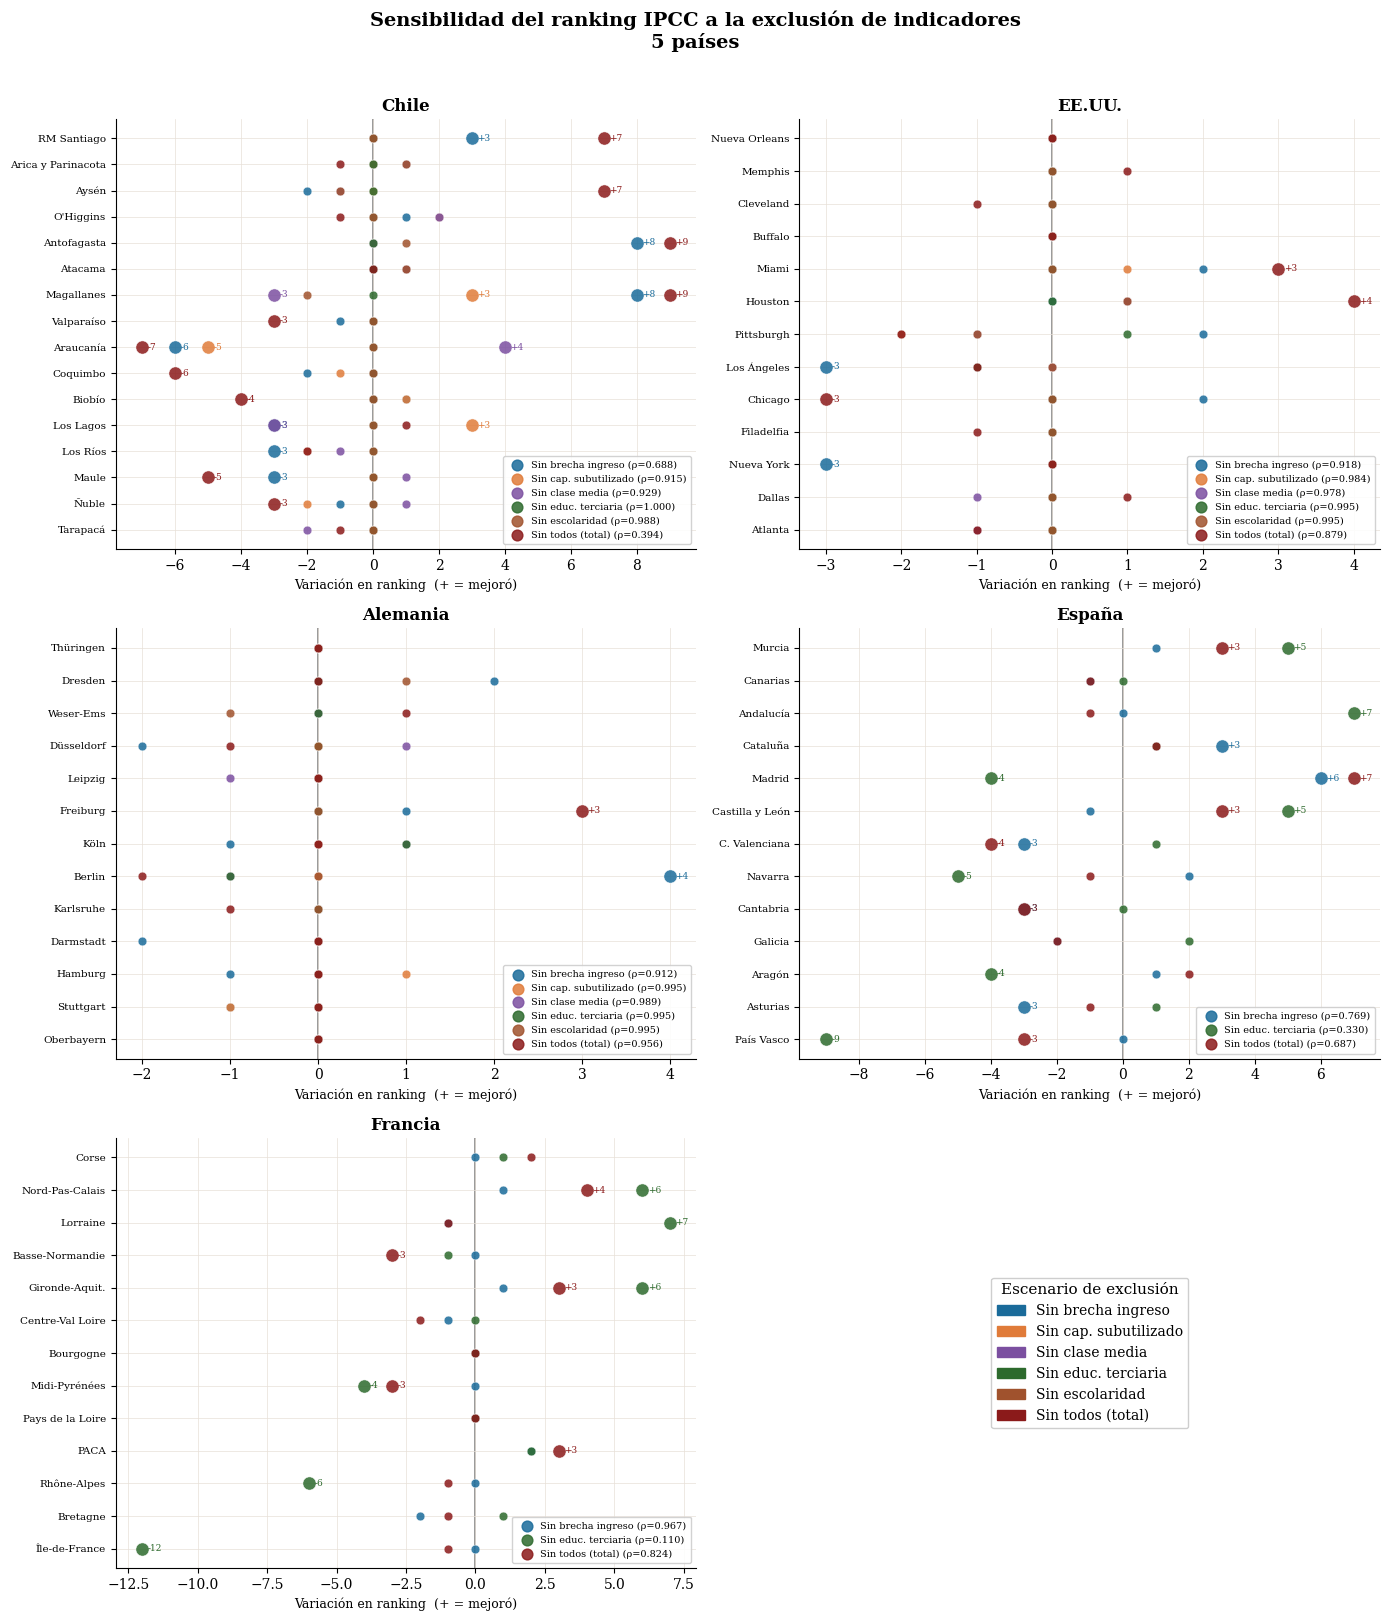

✓ F_S1 guardada: /Users/diego/Desktop/MT/graficos/importantes/sensibilidad_comparada_S1_dotplot_2024.png


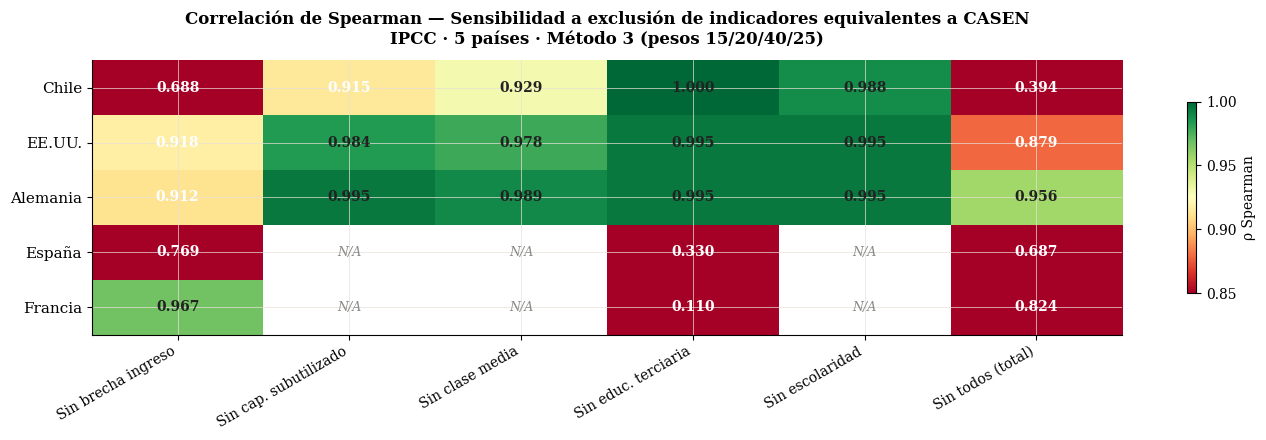

✓ F_S1b guardada: /Users/diego/Desktop/MT/graficos/importantes/sensibilidad_comparada_S1b_heatmap_spearman_2024.png


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 3 — NIVEL 1: FIGURAS F_S1 (DOT PLOT) Y F_S1b (HEATMAP SPEARMAN)
# ══════════════════════════════════════════════════════════════════════════════

# ── Paleta de escenarios (consistente entre países) ───────────────────────
TODOS_ESCENARIOS = [
    'sin_brecha', 'sin_cap_sub', 'sin_clase_media',
    'sin_educ_terc', 'sin_escolaridad', 'sin_CASEN_total'
]
LABELS_ESC = {
    'sin_brecha':     'Sin brecha ingreso',
    'sin_cap_sub':    'Sin cap. subutilizado',
    'sin_clase_media':'Sin clase media',
    'sin_educ_terc':  'Sin educ. terciaria',
    'sin_escolaridad':'Sin escolaridad',
    'sin_CASEN_total':'Sin todos (total)',
}
COLOR_ESC = {
    'sin_brecha':      '#1A6B9A',
    'sin_cap_sub':     '#E07B39',
    'sin_clase_media': '#7B4FA0',
    'sin_educ_terc':   '#2D6A2D',
    'sin_escolaridad': '#A0522D',
    'sin_CASEN_total': '#8B1A1A',
}

PAISES_LISTA = list(PAISES_CFG.keys())

# ── F_S1: Dot plot 3×2 ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes_flat = axes.flatten()

for idx, pais in enumerate(PAISES_LISTA):
    ax  = axes_flat[idx]
    cfg = PAISES_CFG[pais]
    df  = cfg['df']
    nl  = cfg['n_label']
    res = nivel1[pais]['resultados']
    base_ranks = nivel1[pais]['base_ranks']

    orden = np.argsort(base_ranks)
    nombres_ord = df[nl].values[orden]
    n = len(df)
    y_pos = np.arange(n)

    ax.axvline(0, color='#888888', lw=1.2, ls='-', zorder=1)

    for esc in TODOS_ESCENARIOS:
        if esc not in res: continue
        delta = res[esc]['delta'][orden]
        rho   = res[esc]['rho']
        col   = COLOR_ESC[esc]
        label = f"{LABELS_ESC[esc]} (ρ={rho:.3f})"
        for i, (y, d) in enumerate(zip(y_pos, delta)):
            size = 90 if abs(d) >= 3 else 40
            ax.scatter(d, y, color=col, s=size, alpha=0.85, zorder=3,
                       edgecolors='white', linewidths=0.4)
        ax.scatter([], [], color=col, s=60, label=label, alpha=0.85)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(nombres_ord, fontsize=7.5, fontfamily='DejaVu Serif')
    ax.set_xlabel('Variación en ranking  (+ = mejoró)', fontsize=9,
                  fontfamily='DejaVu Serif')
    ax.set_title(pais, fontsize=12, fontweight='bold', fontfamily='DejaVu Serif')
    ax.legend(fontsize=7, loc='lower right', framealpha=0.88, frameon=True,
              ncol=1, handletextpad=0.4, borderpad=0.5)

    for esc in TODOS_ESCENARIOS:
        if esc not in res: continue
        delta = res[esc]['delta'][orden]
        col = COLOR_ESC[esc]
        for i, (y, d) in enumerate(zip(y_pos, delta)):
            if abs(d) >= 3:
                ax.annotate(f'{int(d):+d}', xy=(d, y),
                            xytext=(4, 0), textcoords='offset points',
                            fontsize=6.5, color=col, va='center',
                            fontfamily='DejaVu Serif')

# Celda vacía → leyenda global
ax_leg = axes_flat[5]
ax_leg.axis('off')
handles = [mpatches.Patch(color=COLOR_ESC[e], label=LABELS_ESC[e])
           for e in TODOS_ESCENARIOS]
ax_leg.legend(handles=handles, loc='center', fontsize=10,
              framealpha=0.95, title='Escenario de exclusión',
              title_fontsize=11, edgecolor='#CCCCCC')

fig.suptitle('Sensibilidad del ranking IPCC a la exclusión de indicadores\n'
             '5 países',
             fontsize=14, fontweight='bold', fontfamily='DejaVu Serif', y=1.01)
plt.tight_layout()
ruta1 = f'{FIGDIR}/sensibilidad_comparada_S1_dotplot_2024.png'
plt.savefig(ruta1, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print(f'✓ F_S1 guardada: {ruta1}')

# ── F_S1b: Heatmap correlaciones de Spearman ─────────────────────────────
cols_hm  = TODOS_ESCENARIOS
n_cols   = len(cols_hm)
n_rows   = len(PAISES_LISTA)

rho_matrix = np.zeros((n_rows, n_cols))
for i, pais in enumerate(PAISES_LISTA):
    res = nivel1[pais]['resultados']
    for j, esc in enumerate(cols_hm):
        rho_matrix[i, j] = res[esc]['rho'] if esc in res else np.nan

fig2, ax2 = plt.subplots(figsize=(14, 4.5))
im = ax2.imshow(rho_matrix, aspect='auto', cmap='RdYlGn',
                vmin=0.85, vmax=1.0)
plt.colorbar(im, ax=ax2, shrink=0.7, label='ρ Spearman')

ax2.set_xticks(range(n_cols))
ax2.set_xticklabels([LABELS_ESC[e] for e in cols_hm],
                    rotation=30, ha='right', fontsize=10,
                    fontfamily='DejaVu Serif')
ax2.set_yticks(range(n_rows))
ax2.set_yticklabels(PAISES_LISTA, fontsize=11, fontfamily='DejaVu Serif')

for i in range(n_rows):
    for j in range(n_cols):
        v = rho_matrix[i, j]
        if not np.isnan(v):
            color_txt = 'white' if v < 0.92 else '#222222'
            ax2.text(j, i, f'{v:.3f}', ha='center', va='center',
                     fontsize=10, fontweight='bold', color=color_txt,
                     fontfamily='DejaVu Serif')
        else:
            ax2.text(j, i, 'N/A', ha='center', va='center',
                     fontsize=9, color='#888888', fontstyle='italic',
                     fontfamily='DejaVu Serif')

ax2.set_title(
    'Correlación de Spearman — Sensibilidad a exclusión de indicadores equivalentes a CASEN\n'
    'IPCC · 5 países · Método 3 (pesos 15/20/40/25)',
    fontsize=12, fontweight='bold', fontfamily='DejaVu Serif', pad=12)

plt.tight_layout()
ruta1b = f'{FIGDIR}/sensibilidad_comparada_S1b_heatmap_spearman_2024.png'
plt.savefig(ruta1b, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print(f'✓ F_S1b guardada: {ruta1b}')


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 4 — NIVEL 2: CÁLCULO DE SENSIBILIDAD A VARIACIONES DE PESOS
# ══════════════════════════════════════════════════════════════════════════════
M3_BASE  = (15, 20, 40, 25)   # pesos base en porcentaje
MAX_DELTA = 15                  # máx. cambio permitido por dimensión

combos_validas = [
    w for w in itertools.product(range(10, 51, 5), repeat=4)
    if sum(w) == 100 and max(abs(w[k]-M3_BASE[k]) for k in range(4)) <= MAX_DELTA
]
N_COMBOS = len(combos_validas)
print(f'✓ Combinaciones de pesos válidas: {N_COMBOS}')
print(f'  (rango 10–50% por dimensión, paso 5%, ±{MAX_DELTA}pp vs M3 base)')

nivel2 = {}

for pais, cfg in PAISES_CFG.items():
    df         = cfg['df']
    med_ccpi_b = cfg['med_ccpi']
    med_y_b    = cfg['med_y']
    y_col      = cfg['y_col']
    nl         = cfg['n_label']
    cuad_base  = df[cfg['cuad_col']].values
    base_ranks = nivel1[pais]['base_ranks']
    n_units    = len(df)

    ranks_matrix = np.zeros((N_COMBOS, n_units))
    cuads_matrix = np.empty((N_COMBOS, n_units), dtype=object)

    for ci, w in enumerate(combos_validas):
        wB, wE, wP, wN = [x/100.0 for x in w]
        scores = (wB * df['dim_Business']      + wE * df['dim_Employment']
                + wP * df['dim_Potential']      + wN * df['dim_Entrepreneurial'])
        ranks_matrix[ci] = scores.rank(ascending=False).values
        cuads_matrix[ci] = [
            clasificar_cuadrante(float(c), float(y), med_ccpi_b, med_y_b)
            for c, y in zip(scores, df[y_col])
        ]

    pct_estab = np.array([
        np.mean(cuads_matrix[:, i] == cuad_base[i]) * 100
        for i in range(n_units)
    ])

    nivel2[pais] = {
        'df': df, 'cfg': cfg, 'base_ranks': base_ranks,
        'ranks_matrix': ranks_matrix,
        'cuads_matrix': cuads_matrix,
        'pct_estab':    pct_estab,
        'rank_median':  np.median(ranks_matrix, axis=0),
        'rank_std':     np.std(ranks_matrix, axis=0),
    }

    n_estab   = int((pct_estab > 80).sum())
    n_inest   = int((pct_estab < 60).sum())
    rho_media = float(np.mean([
        spearmanr(base_ranks, ranks_matrix[ci])[0] for ci in range(N_COMBOS)
    ]))
    print(f'\n{pais}:  estab>80%: {n_estab}/{n_units}  '
          f'inest<60%: {n_inest}/{n_units}  '
          f'ρ_media: {rho_media:.4f}  '
          f'rank_std_media: {np.mean(np.std(ranks_matrix,axis=0)):.2f}')

print(f'\n✓ Nivel 2 calculado ({N_COMBOS} combinaciones × {len(PAISES_CFG)} países)')


✓ Combinaciones de pesos válidas: 135
  (rango 10–50% por dimensión, paso 5%, ±15pp vs M3 base)

Chile:  estab>80%: 10/16  inest<60%: 4/16  ρ_media: 0.8938  rank_std_media: 1.42

EE.UU.:  estab>80%: 10/13  inest<60%: 1/13  ρ_media: 0.9864  rank_std_media: 0.41

Alemania:  estab>80%: 10/13  inest<60%: 2/13  ρ_media: 0.9757  rank_std_media: 0.59

España:  estab>80%: 9/13  inest<60%: 4/13  ρ_media: 0.8605  rank_std_media: 1.61

Francia:  estab>80%: 12/13  inest<60%: 0/13  ρ_media: 0.9370  rank_std_media: 1.08

✓ Nivel 2 calculado (135 combinaciones × 5 países)


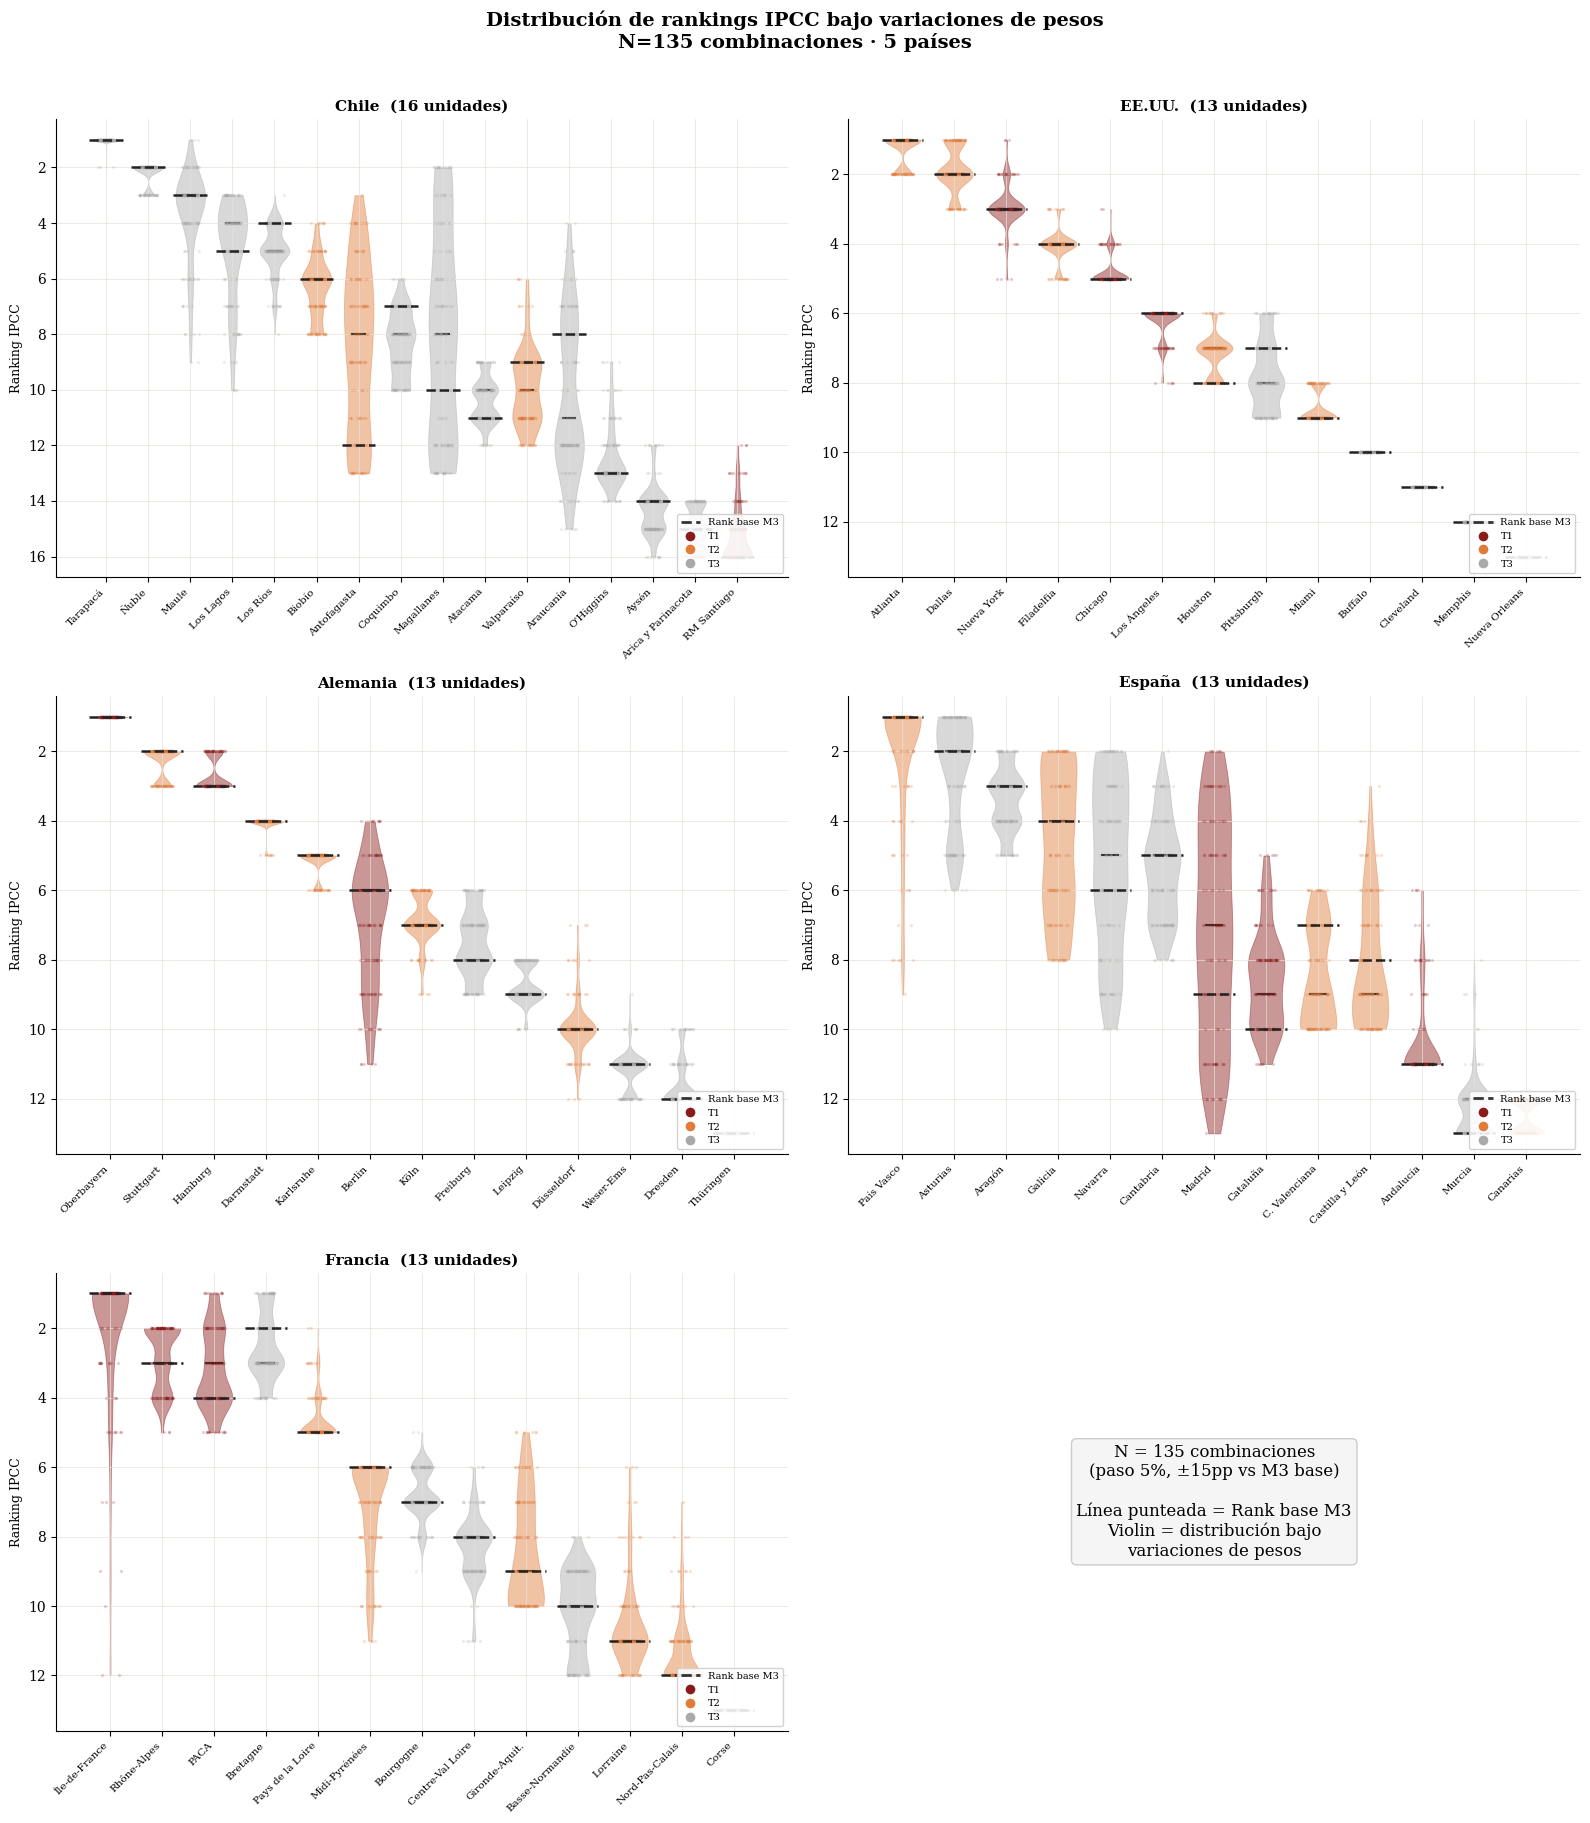

✓ F_S2 guardada: /Users/diego/Desktop/MT/graficos/importantes/sensibilidad_comparada_S2_violin_2024.png


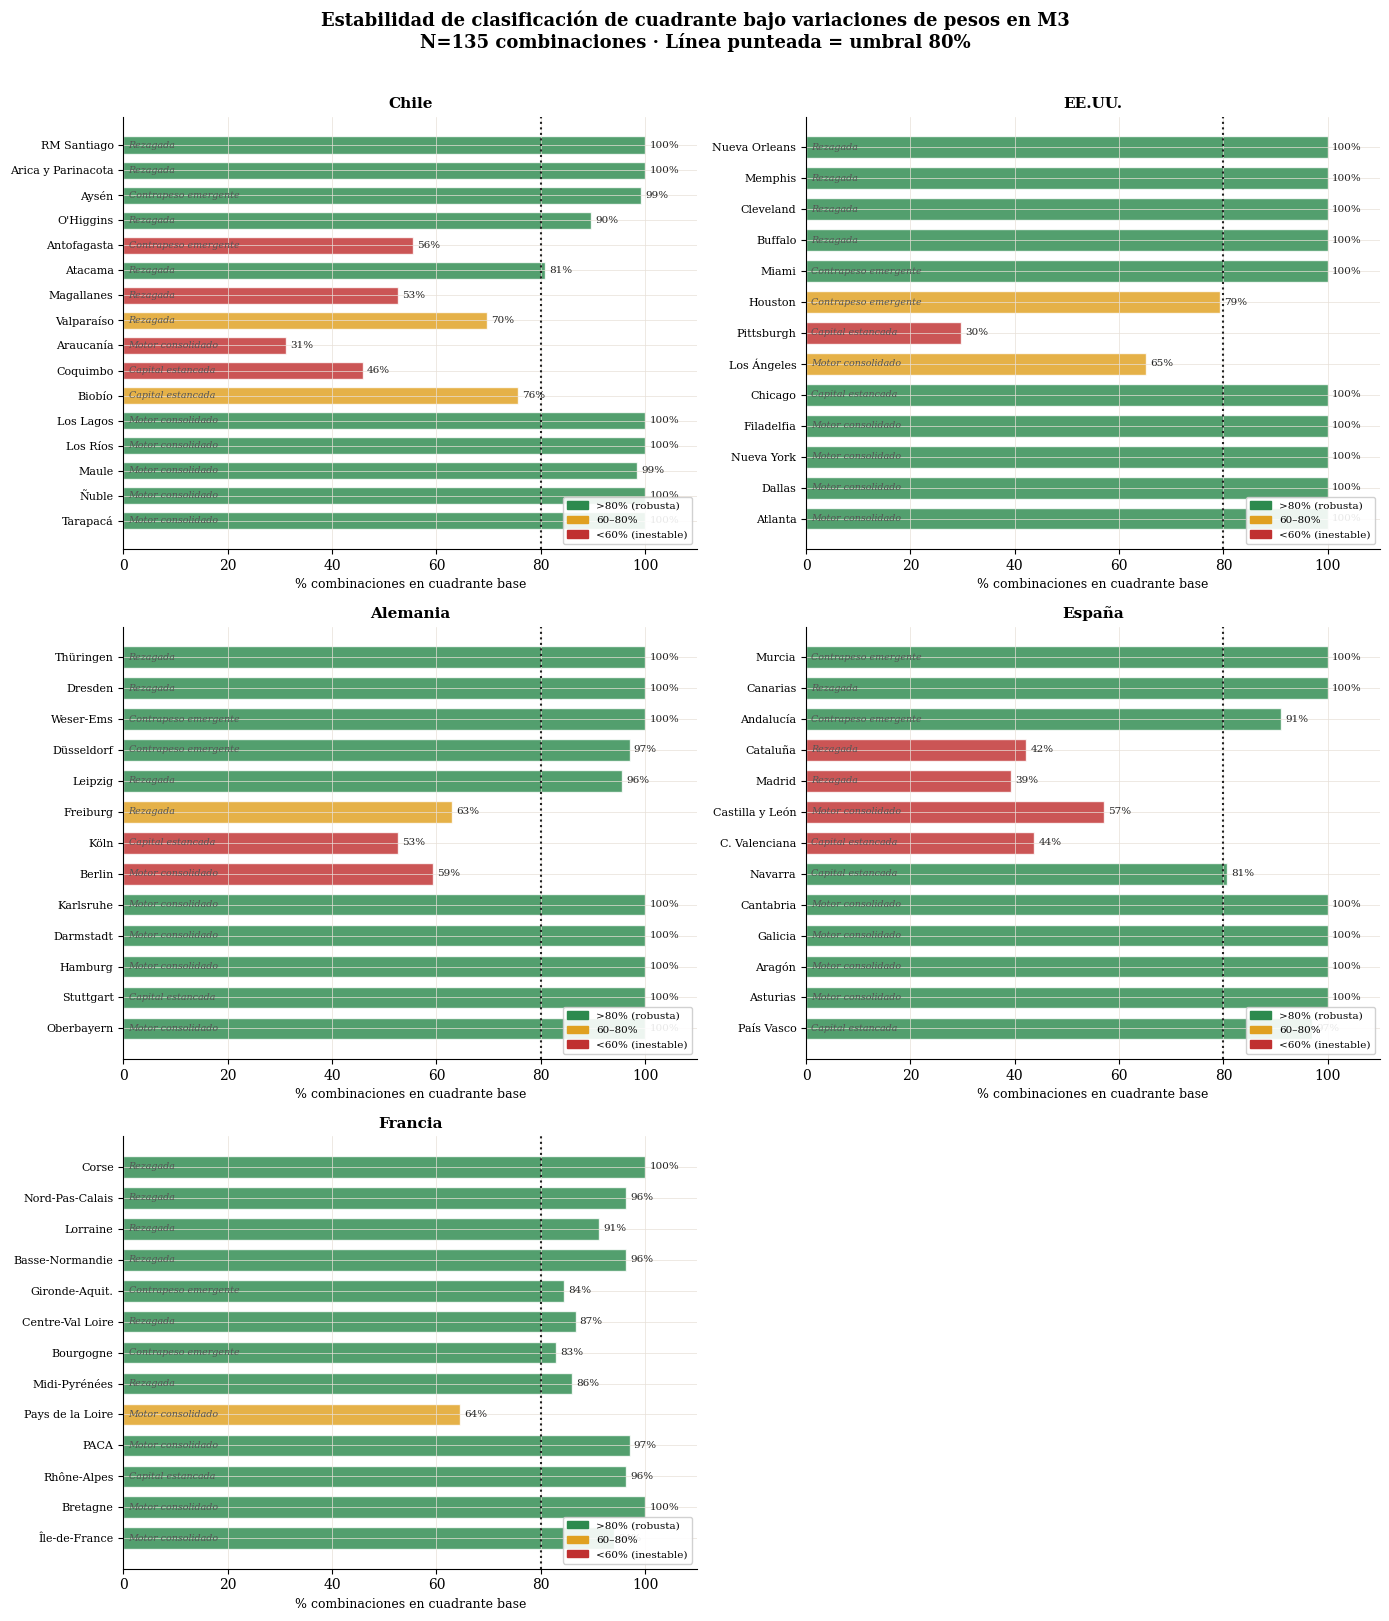

✓ F_S3 guardada: /Users/diego/Desktop/MT/graficos/importantes/sensibilidad_comparada_S3_estabilidad_cuadrante_2024.png


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 5 — NIVEL 2: FIGURA F_S2 (VIOLIN) Y F_S3 (ESTABILIDAD CUADRANTE)
# ══════════════════════════════════════════════════════════════════════════════

# ── F_S2: Violin plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes_flat = axes.flatten()

for idx, pais in enumerate(PAISES_LISTA):
    ax  = axes_flat[idx]
    cfg = PAISES_CFG[pais]
    df  = cfg['df']
    nl  = cfg['n_label']
    d2  = nivel2[pais]

    rank_med    = d2['rank_median']
    orden       = np.argsort(rank_med)
    nombres_ord = df[nl].values[orden]
    base_ranks  = d2['base_ranks'][orden]
    ranks_mat   = d2['ranks_matrix'][:, orden]  # (N_COMBOS, n_units)
    tiers       = df['tier'].values[orden]
    n = len(df)

    x_pos = np.arange(n)
    violins_data = [ranks_mat[:, i] for i in range(n)]

    vp = ax.violinplot(violins_data, positions=x_pos,
                       showmeans=False, showmedians=True, showextrema=False,
                       widths=0.7)

    # Colorear violines por tier
    for i, (pc, body) in enumerate(zip(x_pos, vp['bodies'])):
        t  = int(tiers[i])
        body.set_facecolor(COLOR_TIER[t])
        body.set_alpha(0.45)
        body.set_edgecolor(COLOR_TIER[t])
        body.set_linewidth(0.6)

    vp['cmedians'].set_colors('#333333')
    vp['cmedians'].set_linewidth(1.5)

    # Strip plot
    for i in range(n):
        t = int(tiers[i])
        jitter = np.random.default_rng(42 + i).uniform(-0.22, 0.22, N_COMBOS)
        ax.scatter(x_pos[i] + jitter, ranks_mat[:, i],
                   color=COLOR_TIER[t], s=2, alpha=0.15, zorder=2)

    # Rank base M3 — línea horizontal por unidad
    for i, rb in enumerate(base_ranks):
        ax.hlines(rb, x_pos[i]-0.4, x_pos[i]+0.4,
                  colors='#222222', linewidths=1.8, zorder=4, linestyles='--')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(nombres_ord, rotation=45, ha='right',
                       fontsize=7.5, fontfamily='DejaVu Serif')
    ax.invert_yaxis()
    ax.set_ylabel('Ranking IPCC', fontsize=9, fontfamily='DejaVu Serif')
    ax.set_title(f'{pais}  ({n} unidades)',
                 fontsize=11, fontweight='bold', fontfamily='DejaVu Serif')

    leg = [Line2D([0],[0], color='#333', lw=2, ls='--', label='Rank base M3')] + [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_TIER[t],
               markersize=8, label=f'T{t}')
        for t in sorted(df['tier'].unique())
    ]
    ax.legend(handles=leg, fontsize=7, framealpha=0.88, loc='lower right')

# Celda vacía
axes_flat[5].axis('off')
axes_flat[5].text(0.5, 0.5,
    f'N = {N_COMBOS} combinaciones\n'
    f'(paso 5%, ±{MAX_DELTA}pp vs M3 base)\n\n'
    f'Línea punteada = Rank base M3\n'
    f'Violin = distribución bajo\nvariaciones de pesos',
    ha='center', va='center', fontsize=12, fontfamily='DejaVu Serif',
    transform=axes_flat[5].transAxes,
    bbox=dict(boxstyle='round', fc='#F5F5F5', ec='#CCCCCC'))

fig.suptitle(
    f'Distribución de rankings IPCC bajo variaciones de pesos\n'
    f'N={N_COMBOS} combinaciones · 5 países',
    fontsize=14, fontweight='bold', fontfamily='DejaVu Serif', y=1.01)
plt.tight_layout()
ruta2 = f'{FIGDIR}/sensibilidad_comparada_S2_violin_2024.png'
plt.savefig(ruta2, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print(f'✓ F_S2 guardada: {ruta2}')

# ── F_S3: Estabilidad de cuadrante ───────────────────────────────────────
fig3, axes3 = plt.subplots(3, 2, figsize=(14, 16))
axes3_flat  = axes3.flatten()

def color_estab(pct):
    if pct > 80:  return '#2D8A4E'
    if pct >= 60: return '#E0A020'
    return '#C03030'

for idx, pais in enumerate(PAISES_LISTA):
    ax  = axes3_flat[idx]
    cfg = PAISES_CFG[pais]
    df  = cfg['df']
    nl  = cfg['n_label']
    d2  = nivel2[pais]

    base_ranks  = d2['base_ranks']
    pct_estab   = d2['pct_estab']
    cuad_base   = df[cfg['cuad_col']].values

    orden       = np.argsort(base_ranks)
    nombres_ord = df[nl].values[orden]
    pct_ord     = pct_estab[orden]
    cuad_ord    = cuad_base[orden]
    tiers_ord   = df['tier'].values[orden]
    n           = len(df)
    y_pos       = np.arange(n)

    colors_bar  = [color_estab(p) for p in pct_ord]
    ax.barh(y_pos, pct_ord, color=colors_bar, alpha=0.82, edgecolor='white', height=0.7)
    ax.axvline(80, color='#222222', lw=1.5, ls=':', zorder=5)

    for i, (y, pct, cuad, t) in enumerate(zip(y_pos, pct_ord, cuad_ord, tiers_ord)):
        ax.text(pct + 0.8, y, f'{pct:.0f}%', va='center', fontsize=7.5,
                fontfamily='DejaVu Serif', color='#222222')
        ax.text(1, y, cuad, va='center', ha='left', fontsize=6.8,
                fontfamily='DejaVu Serif', color='#555555', fontstyle='italic')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(nombres_ord, fontsize=8, fontfamily='DejaVu Serif')
    ax.set_xlim(0, 110)
    ax.set_xlabel('% combinaciones en cuadrante base', fontsize=9,
                  fontfamily='DejaVu Serif')
    ax.set_title(pais, fontsize=11, fontweight='bold', fontfamily='DejaVu Serif')

    # mini-leyenda colores
    leg3 = [
        mpatches.Patch(color='#2D8A4E', label='>80% (robusta)'),
        mpatches.Patch(color='#E0A020', label='60–80%'),
        mpatches.Patch(color='#C03030', label='<60% (inestable)'),
    ]
    ax.legend(handles=leg3, fontsize=7.5, loc='lower right', framealpha=0.9)

# celda vacía
axes3_flat[5].axis('off')

fig3.suptitle(
    'Estabilidad de clasificación de cuadrante bajo variaciones de pesos en M3\n'
    f'N={N_COMBOS} combinaciones · Línea punteada = umbral 80%',
    fontsize=13, fontweight='bold', fontfamily='DejaVu Serif', y=1.01)
plt.tight_layout()
ruta3 = f'{FIGDIR}/sensibilidad_comparada_S3_estabilidad_cuadrante_2024.png'
plt.savefig(ruta3, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print(f'✓ F_S3 guardada: {ruta3}')


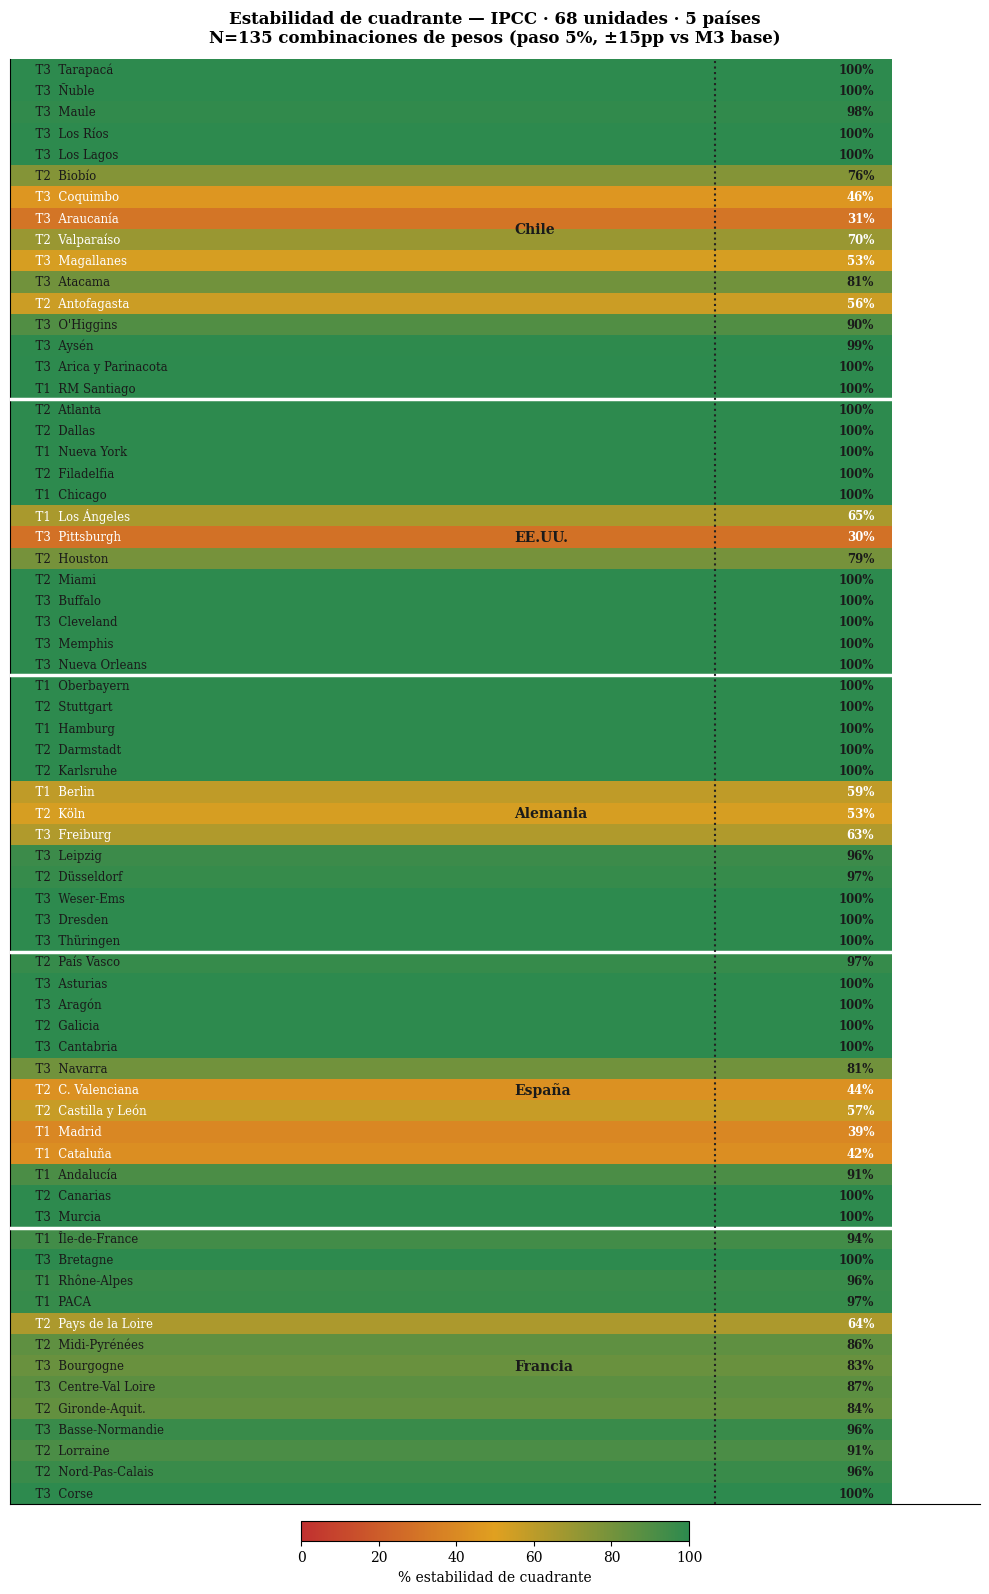

✓ F_S4 guardada: /Users/diego/Desktop/MT/graficos/importantes/sensibilidad_comparada_S4_heatmap_estabilidad_2024.png


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 6 — NIVEL 2: FIGURA F_S4 (HEATMAP ESTABILIDAD TODAS LAS UNIDADES)
# ══════════════════════════════════════════════════════════════════════════════

# Construir lista ordenada de todas las unidades (agrupadas por país)
rows_hm = []
for pais in PAISES_LISTA:
    cfg        = PAISES_CFG[pais]
    df         = cfg['df']
    nl         = cfg['n_label']
    d2         = nivel2[pais]
    base_ranks = d2['base_ranks']
    pct_estab  = d2['pct_estab']
    cuad_base  = df[cfg['cuad_col']].values
    tiers      = df['tier'].values

    orden = np.argsort(base_ranks)
    for i in orden:
        rows_hm.append({
            'pais':       pais,
            'region':     df[nl].values[i],
            'tier':       int(tiers[i]),
            'rank_base':  int(base_ranks[i]),
            'pct_estab':  round(float(pct_estab[i]), 1),
            'cuad_base':  cuad_base[i],
        })

df_hm = pd.DataFrame(rows_hm)
N_TOTAL = len(df_hm)

# Asignar separadores visuales por país
pais_limits = []
idx = 0
for pais in PAISES_LISTA:
    n = (df_hm['pais'] == pais).sum()
    pais_limits.append((idx, idx + n - 1, pais))
    idx += n

# Colormap personalizado: verde/amarillo/rojo
from matplotlib.colors import LinearSegmentedColormap
cmap_estab = LinearSegmentedColormap.from_list(
    'estab', ['#C03030','#E0A020','#2D8A4E'], N=256)

fig4, ax4 = plt.subplots(figsize=(10, 18))

# Una sola columna: % estabilidad (barplot horizontal con heatmap de fondo)
# Usamos imshow con 1 columna y altura N_TOTAL filas
data_hm = df_hm['pct_estab'].values.reshape(-1, 1)
im4 = ax4.imshow(data_hm, aspect='auto', cmap=cmap_estab,
                 vmin=0, vmax=100, extent=[-0.5, 0.5, N_TOTAL-0.5, -0.5])

# Anotaciones por fila
for i, row in df_hm.iterrows():
    ax4.text(-0.48, i, f"  T{row['tier']}  {row['region']:<22}",
             va='center', ha='left', fontsize=8.5, fontfamily='DejaVu Serif',
             color='white' if row['pct_estab'] < 70 else '#1A1A1A')
    ax4.text(0.48, i, f"{row['pct_estab']:.0f}%",
             va='center', ha='right', fontsize=8.5, fontfamily='DejaVu Serif',
             color='white' if row['pct_estab'] < 70 else '#1A1A1A',
             fontweight='bold')

# Líneas de separación por país y etiquetas
offset = 0
for start, end, pais in pais_limits:
    if start > 0:
        ax4.axhline(start - 0.5, color='white', lw=2.5, zorder=5)
    # Etiqueta de país en el margen derecho
    mid = (start + end) / 2
    ax4.text(0.52, mid, pais, va='center', ha='left', fontsize=10,
             fontfamily='DejaVu Serif', fontweight='bold', color='#1A1A1A',
             transform=ax4.get_yaxis_transform())

# Línea umbral 80%
ax4.axvline(0.3, color='#222222', lw=1.5, ls=':', zorder=6,
            label='Umbral 80%')  # posición relativa en escala imshow [-0.5, 0.5]

ax4.set_xlim(-0.5, 0.6)
ax4.set_ylim(N_TOTAL - 0.5, -0.5)
ax4.set_xticks([])
ax4.set_yticks([])

plt.colorbar(im4, ax=ax4, shrink=0.4, label='% estabilidad de cuadrante',
             orientation='horizontal', pad=0.01)
ax4.set_title(
    f'Estabilidad de cuadrante — IPCC · {N_TOTAL} unidades · 5 países\n'
    f'N={N_COMBOS} combinaciones de pesos (paso 5%, ±{MAX_DELTA}pp vs M3 base)',
    fontsize=12, fontweight='bold', fontfamily='DejaVu Serif', pad=12)

plt.tight_layout()
ruta4 = f'{FIGDIR}/sensibilidad_comparada_S4_heatmap_estabilidad_2024.png'
plt.savefig(ruta4, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print(f'✓ F_S4 guardada: {ruta4}')


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 7 — TABLA RESUMEN CONSOLIDADA + PRINT FINAL
# ══════════════════════════════════════════════════════════════════════════════

# ── Tabla CSV consolidada ─────────────────────────────────────────────────
todos_escenarios_l1 = [
    'sin_brecha','sin_cap_sub','sin_clase_media',
    'sin_educ_terc','sin_escolaridad','sin_CASEN_total'
]

filas_csv = []
for pais in PAISES_LISTA:
    cfg        = PAISES_CFG[pais]
    df         = cfg['df']
    nl         = cfg['n_label']
    d1         = nivel1[pais]
    d2         = nivel2[pais]
    base_ranks = d1['base_ranks']
    res        = d1['resultados']

    for i, (_, row) in enumerate(df.iterrows()):
        fila = {
            'Pais':           pais,
            'Region':         row[nl],
            'Tier':           int(row['tier']),
            'Rank_base':      int(base_ranks[i]),
            'Rank_mediano':   round(float(d2['rank_median'][i]), 2),
            'Rank_std':       round(float(d2['rank_std'][i]), 2),
            'Cuadrante_base': row[cfg['cuad_col']],
            'Pct_estabilidad':round(float(d2['pct_estab'][i]), 1),
        }
        for esc in todos_escenarios_l1:
            key = f'Spearman_{esc}'
            fila[key] = res[esc]['rho'] if esc in res else None
        filas_csv.append(fila)

df_csv = (pd.DataFrame(filas_csv)
          .sort_values(['Pais','Rank_base'])
          .reset_index(drop=True))

ruta_csv = f'{FIGDIR}/sensibilidad_comparada_2024.csv'
df_csv.to_csv(ruta_csv, index=False, encoding='utf-8-sig')
print(f'✓ CSV guardado: {ruta_csv}')
print(f'  {len(df_csv)} filas × {len(df_csv.columns)} columnas\n')

from IPython.display import display
display(df_csv)

# ── Resumen integrado por país ────────────────────────────────────────────
print('\n' + '='*78)
print('  RESUMEN ANÁLISIS DE SENSIBILIDAD COMPARADO CCPI_M3')
print('='*78)

for pais in PAISES_LISTA:
    d1  = nivel1[pais]
    d2  = nivel2[pais]
    cfg = PAISES_CFG[pais]
    df  = cfg['df']
    nl  = cfg['n_label']
    res = d1['resultados']

    # Nivel 1
    rhos = {e: v['rho'] for e, v in res.items() if e != 'base'}
    esc_max = max(rhos, key=lambda e: rhos[e])
    esc_min = min(rhos, key=lambda e: rhos[e])
    rho_total = res['sin_CASEN_total']['rho'] if 'sin_CASEN_total' in res else None

    # Nivel 2
    pct_estab   = d2['pct_estab']
    names       = df[nl].values
    estab_list  = [names[i] for i in range(len(df)) if pct_estab[i] > 80]
    inest_list  = [names[i] for i in range(len(df)) if pct_estab[i] < 60]
    rho_media   = float(np.mean([
        spearmanr(d2['base_ranks'], d2['ranks_matrix'][ci])[0]
        for ci in range(N_COMBOS)
    ]))

    print(f'\n  ── {pais} ──')
    print(f'  Nivel 1 — Escenario más robusto:    {LABELS_ESC.get(esc_max, esc_max):<28} ρ = {rhos[esc_max]:.4f}')
    print(f'  Nivel 1 — Escenario más sensible:   {LABELS_ESC.get(esc_min, esc_min):<28} ρ = {rhos[esc_min]:.4f}')
    if rho_total is not None:
        print(f'  Nivel 1 — Sin equivalentes CASEN:   ρ = {rho_total:.4f}')
    print(f'  Nivel 2 — Unidades estables (>80%): {", ".join(estab_list) if estab_list else "ninguna"}')
    print(f'  Nivel 2 — Unidades inestables (<60%): {", ".join(inest_list) if inest_list else "ninguna"}')
    print(f'  Nivel 2 — Correlación media entre rankings: {rho_media:.4f}')

print('\n' + '='*78)
print(f'\n  Figuras guardadas en: {FIGDIR}/')
for fn in [
    'sensibilidad_comparada_S1_dotplot_2024.png',
    'sensibilidad_comparada_S1b_heatmap_spearman_2024.png',
    'sensibilidad_comparada_S2_violin_2024.png',
    'sensibilidad_comparada_S3_estabilidad_cuadrante_2024.png',
    'sensibilidad_comparada_S4_heatmap_estabilidad_2024.png',
    'sensibilidad_comparada_2024.csv',
]:
    print(f'    {fn}')


✓ CSV guardado: /Users/diego/Desktop/MT/graficos/importantes/sensibilidad_comparada_2024.csv
  68 filas × 14 columnas



,Pais,Region,Tier,Rank_base,Rank_mediano,Rank_std,Cuadrante_base,Pct_estabilidad,Spearman_sin_brecha,Spearman_sin_cap_sub,Spearman_sin_clase_media,Spearman_sin_educ_terc,Spearman_sin_escolaridad,Spearman_sin_CASEN_total
0,Alemania,Oberbayern,1,1,1.0,0.00,Motor consolidado,100.0,0.9121,0.9945,0.989,0.9945,0.9945,0.9560
1,Alemania,Stuttgart,2,2,2.0,0.47,Capital estancada,100.0,0.9121,0.9945,0.989,0.9945,0.9945,0.9560
2,Alemania,Hamburg,1,3,3.0,0.47,Motor consolidado,100.0,0.9121,0.9945,0.989,0.9945,0.9945,0.9560
3,Alemania,Darmstadt,2,4,4.0,0.24,Motor consolidado,100.0,0.9121,0.9945,0.989,0.9945,0.9945,0.9560
4,Alemania,Karlsruhe,2,5,5.0,0.39,Motor consolidado,100.0,0.9121,0.9945,0.989,0.9945,0.9945,0.9560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,Francia,Gironde-Aquit.,2,9,9.0,1.56,Contrapeso emergente,84.4,0.9670,NaN,NaN,0.1099,NaN,0.8242
64,Francia,Basse-Normandie,3,10,10.0,1.18,Rezagada,96.3,0.9670,NaN,NaN,0.1099,NaN,0.8242
65,Francia,Lorraine,2,11,11.0,1.29,Rezagada,91.1,0.9670,NaN,NaN,0.1099,NaN,0.8242
66,Francia,Nord-Pas-Calais,2,12,12.0,1.02,Rezagada,96.3,0.9670,NaN,NaN,0.1099,NaN,0.8242



  RESUMEN ANÁLISIS DE SENSIBILIDAD COMPARADO CCPI_M3

  ── Chile ──
  Nivel 1 — Escenario más robusto:    Sin educ. terciaria          ρ = 1.0000
  Nivel 1 — Escenario más sensible:   Sin todos (total)            ρ = 0.3941
  Nivel 1 — Sin equivalentes CASEN:   ρ = 0.3941
  Nivel 2 — Unidades estables (>80%): Arica y Parinacota, Atacama, O'Higgins, Maule, Los Lagos, Aysén, RM Santiago, Los Ríos, Tarapacá, Ñuble
  Nivel 2 — Unidades inestables (<60%): Antofagasta, Coquimbo, Araucanía, Magallanes
  Nivel 2 — Correlación media entre rankings: 0.8938

  ── EE.UU. ──
  Nivel 1 — Escenario más robusto:    Sin educ. terciaria          ρ = 0.9945
  Nivel 1 — Escenario más sensible:   Sin todos (total)            ρ = 0.8791
  Nivel 1 — Sin equivalentes CASEN:   ρ = 0.8791
  Nivel 2 — Unidades estables (>80%): Nueva York, Chicago, Dallas, Filadelfia, Miami, Atlanta, Cleveland, Memphis, Buffalo, Nueva Orleans
  Nivel 2 — Unidades inestables (<60%): Pittsburgh
  Nivel 2 — Correlación media entre 